# Phase Hyperparameters:

Considered Hyperparameters:
- Macro-structure:
  - Layers
  - Neurons
  - Multiplicity
- Micro-structure:
  - Grid
  - Order
  - Initial Function (function, noise scale, seed)
- Training:
  - Solver
  - Learning rate
  - Epochs
  - Pruning
  - Refinement

## [0]

In [37]:
# --- Imports
import torch
torch.set_default_dtype(torch.float64)
for i in range(torch.cuda.device_count()):
    print(f'Device: {torch.cuda.get_device_properties(i).name}')
if torch.cuda.is_available():
    i = 0
    torch.cuda.set_device(i)
    device = f'cuda:{i}'
    torch.set_default_device(f'cuda:{i}')
    print(f"Cuda is available. Setting default device to: {torch.cuda.get_device_properties(i).name}")
else:
    print('Cuda is not available. Setting default device to: CPU')
    device = 'cpu'

import kan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time as timing
import itertools

Device: NVIDIA T400 4GB
Cuda is available. Setting default device to: NVIDIA T400 4GB


In [22]:
# --- Model Wrapper
class KanModel:
# Initialize model
    def __init__(
                 self,
                 dataset,
                 hidden_layers,
                 device,
                 **kwargs
                 ):
        n_inputs = dataset['train_input'].shape[1]
        n_outpts = dataset['train_label'].shape[1]
        width = [n_inputs] + hidden_layers + [n_outpts]

        self.model = kan.KAN(width=width, device=device, **kwargs)
        self.dataset = dataset
        self.history = {"train":[],"tests":[]}
        self.device = device
        return
# Train model
    def fit(
            self,
            dataset = None,
            **kwargs
           ):
        dataset = dataset if dataset else self.dataset
        results = self.model.fit(dataset, **kwargs)
        self.history['train'] += results['train_loss']
        self.history['tests'] += results['test_loss']
        return results
# Prune model
    def prune(
              self,
              node_th = None,
              edge_th = None,
              input_th = None,
              **kwargs
             ):
        if node_th:
            try:
                self.model = self.model.prune_node(node_th, **kwargs)
            except:
                print("Node pruning failed.")
        if edge_th:
            try:
                self.model.prune_edge(edge_th)
            except:
                print('Edge pruning failed.')
        if input_th:
            try:
                self.model = self.model.prune_input(input_th)
            except:
                print('Input pruning failed.')
        return
# Refine model
    def refine(
               self,
               num = 0,
               factor = 1,
               **kwargs,
              ):
        new_grid = num if num else self.model.grid * factor 
        #print(new_grid)
        self.model = self.model.refine(new_grid)
        #print(self.model.grid)
        return
# Plot model training
    def plot_training(
                      self,
                      **kwargs
                     ):
        fig, axs = plt.subplots(1,1)
        axs.plot([i for i in range(len(self.history["train"]))], self.history["train"], label='Training')
        axs.plot([i for i in range(len(self.history["tests"]))], self.history["tests"], label='Testing')
        axs.set_yscale('log'); axs.set_ylabel('Loss');axs.set_xlabel("Steps"); axs.grid(visible=True, which='both'); axs.legend(loc='upper right')
        fig.tight_layout()
        return fig
# Plot model performance
    def plot_performance(
                         self,
                         dataset = None,
                         **kwargs
                        ):
        
        Y_TRUE = dataset['test_label'] if dataset else self.dataset['test_label']
        Y_PREDICTED = self.model(dataset['test_input']) if dataset else self.model(self.dataset['test_input'])

        Y_TRUE = Y_TRUE.detach().cpu().numpy()
        Y_PREDICTED = Y_PREDICTED.detach().cpu().numpy()

        fig, axs = plt.subplots(1,2, figsize=(12,4))

        ax=axs[0]
        ax.scatter(Y_TRUE, Y_PREDICTED, alpha=0.25, label=f"Model")
        ax.plot(np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100),np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100), color='black',ls='--', label="True")
        ax.set_xlabel("f(x)"); ax.set_ylabel("KAN(x)"); ax.legend(); ax.grid(visible=True, color='gainsboro')

        ax=axs[1]
        residuals = Y_PREDICTED[:,0] - Y_TRUE[:,0]
        pdf_fit = scipy.stats.norm.fit(residuals)
        pdf_pdf = scipy.stats.norm.pdf(np.linspace(-0.3,0.3,100), *pdf_fit)
        ax.hist(residuals, bins=100, color='cornflowerblue', density=True)
        ax.plot(np.linspace(-0.3,0.3,100), pdf_pdf, label=f'Fit: {[round(i,3) for i in pdf_fit]}')
        ax.set_xlabel("Residual"); ax.set_ylabel("Relative Frequency"); ax.grid(visible=True, color='gainsboro', label='Raw Data'); ax.legend()

        fig.tight_layout()
        return
# Evaluate model performance
    def evaluate_performance(
                            self,
                            dataset = None,
                            **kwargs,
                            ):
        nx = dataset['test_input'].shape[1] if dataset else self.dataset['test_input'].shape[1]
        Y_TRUE = dataset['test_label'].cpu().numpy() if dataset else self.dataset['test_label'].detach().cpu().numpy()
        n = Y_TRUE.shape[0]
        Y_PREDICTED = self.model(dataset['test_input']).detach().cpu().numpy() if dataset else self.model(self.dataset['test_input']).detach().cpu().numpy()
        r2 = r2_score(Y_TRUE, Y_PREDICTED)
        mae = mean_absolute_error(Y_TRUE, Y_PREDICTED)
        mse = mean_squared_error(Y_TRUE, Y_PREDICTED)
        adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-nx-1))
        rmse = np.sqrt(mse)
        maxerr = np.max(Y_PREDICTED/Y_TRUE - 1)
        print(f"R2: {r2}\tMAE: {mae}\tMSE: {mse}\tAdjR2 {adjusted_r2}\tRMSE: {rmse}\tMaxAE: {maxerr}")
        return {'R2':r2, 'MAE':mae, 'MSE':mse, 'adjR2':adjusted_r2, 'RMSE':rmse, 'MaxAE':maxerr}
# Plot model
    def plot(
             self,
             **kwargs
            ):
        self.model.plot(**kwargs)
        return
# Fix and obtain symbolic functions
    def symbolize(
                  self,
                  library = None,
                  **kwargs
                  ):
        self.model.auto_symbolic(library)
        return kan.utils.ex_round(self.model.symbolic_formula()[0][0],4) # type:ignore

In [23]:
# --- Alternative Generator
def generate_dataset(
                     function,
                     n_ins,
                     n_out,
                     train_num = 1000,
                     tests_num = 1000,
                     ranges = [[-1,1]],
                     device = 'cpu',
                     random_state = 43,
                     generator = scipy.stats.uniform,
                     **kwargs
                     ):
    if len(ranges) == 1:
        ranges = [ranges[0] for i in range(n_ins)]
    # Templates
    train_inputs = torch.zeros((train_num, n_ins))
    tests_inputs = torch.zeros((tests_num, n_ins))
    # Sample from inputs
    for i in range(n_ins):
        train_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], train_num, random_state=random_state+i))
    for i in range(n_ins):
        tests_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], tests_num, random_state=random_state+n_ins+i))
    # Compute outputs
    train_output = function(train_inputs)
    tests_output = function(tests_inputs)

    # Compute means and stds
    train_inputs_mu = torch.mean(train_inputs,0)
    train_inputs_sd = torch.std(train_inputs,0)
    tests_inputs_mu = torch.mean(tests_inputs,0)
    tests_inputs_sd = torch.std(tests_inputs,0)

    train_output_mu = torch.mean(train_output,0)
    train_output_sd = torch.std(train_output,0)
    tests_output_mu = torch.mean(tests_output,0)
    tests_output_sd = torch.std(tests_output,0)
    # Normalize
    train_inputs = (train_inputs - train_inputs_mu)/train_inputs_sd
    tests_inputs = (tests_inputs - tests_inputs_mu)/tests_inputs_sd
    train_output = (train_output - train_output_mu)/train_output_sd
    tests_output = (tests_output - tests_output_mu)/tests_output_sd
    # Package
    return_dict = {
                   'train_input':train_inputs.to(device),
                   'test_input':tests_inputs.to(device),
                   'train_label':train_output.to(device),
                   'test_label':tests_output.to(device)
                   }
    stats_dict = {
                  'train_input':(train_inputs_mu.to(device), train_inputs_sd.to(device)),
                  'test_input':(tests_inputs_mu.to(device), tests_inputs_sd.to(device)),
                  'train_label':(train_output_mu.to(device), train_output_sd.to(device)),
                  'test_label':(tests_output_mu.to(device), tests_output_sd.to(device)),
                  }
    return return_dict, stats_dict

## [1]

In [24]:
f = lambda x: torch.tanh(5*(x[:,[0]]**4 + x[:,[1]]**4 + x[:,[2]]**4 - 1))
dataset, statistics = generate_dataset(f, 3, 1, 20000, 2000, ranges=[[-1.2,1.2]], device='cuda:0')
print(dataset['test_input'].shape)
print(dataset['test_label'].shape)

torch.Size([2000, 3])
torch.Size([2000, 1])


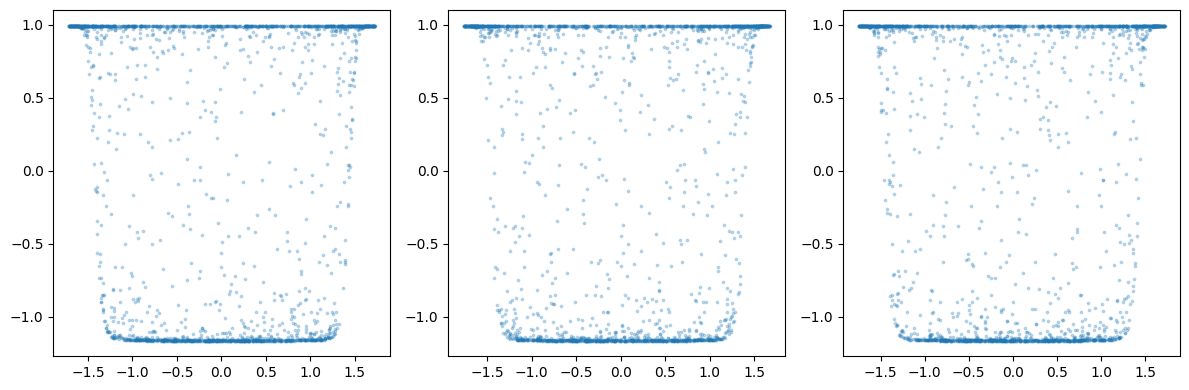

In [25]:
fig, axs = plt.subplots(1,3, figsize=(12,4))

ax=axs[0]
ax.scatter(dataset['test_input'][:,0].cpu(), dataset['test_label'][:,0].cpu(), s=3, alpha=0.25)

ax=axs[1]
ax.scatter(dataset['test_input'][:,1].cpu(), dataset['test_label'][:,0].cpu(), s=3, alpha=0.25)

ax=axs[2]
ax.scatter(dataset['test_input'][:,2].cpu(), dataset['test_label'][:,0].cpu(), s=3, alpha=0.25)

fig.tight_layout()

## [2] Construction Hyperparameters

### [2.0]

In [26]:
def evaluate_hyprm(
                   construction_args: dict,
                   training_args: dict,
                   dataset: dict
                   ):
    
    timer0 = timing.time()
    quickmodel = KanModel(dataset, **construction_args, device=device)
    quickmodel.fit(dataset, **training_args)
    metrics = quickmodel.evaluate_performance(dataset)
    timer1 = timing.time()
    metrics['runtime'] = timer1 - timer0

    return metrics

### [2.1] Layers and Neurons

Consistent initialization function, grid, order, solver, learning rate, epochs, and no pruning/refinement. Because the analytical solution and optimum KAN solution is known, we will restrict the range to [1,2] layers of [2,3,4,5] neurons.

In [50]:
layer_options = [1,2]
neuron_options = [2,3,4,5]

hyprm_options = list(itertools.product(layer_options, neuron_options))
construction_args={'hidden_layers':[4]}
training_args={'steps':50, 'opt':'Adam', 'lr':0.1, 'lamb':0.01, 'singularity_avoiding': True}

In [51]:
results = []
for layers, neurons in hyprm_options:
    construction_args['hidden_layers'] = [neurons for l in range(layers)]
    rdict = (evaluate_hyprm(
                            construction_args=construction_args,
                            training_args=training_args,
                            dataset=dataset
                            ))
    rdict['layers'] = layers
    rdict['neurons'] = neurons
    results.append(rdict)
print(len(results))
print(len(results[0].keys()))
results = pd.DataFrame(results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.86e-01 | test_loss: 2.99e-01 | reg: 1.09e+01 | : 100%|█| 50/50 [00:03<00:00, 14.76it


saving model version 0.1
R2: 0.9105122971408048	MAE: 0.22389368984047803	MSE: 0.08944295900776555	AdjR2 0.9103777965854052	RMSE: 0.29907015733396997	MaxAE: 18.06767330557547
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.52e-01 | test_loss: 2.63e-01 | reg: 8.89e+00 | : 100%|█| 50/50 [00:03<00:00, 15.86it


saving model version 0.1
R2: 0.930582442043109	MAE: 0.2014534838483523	MSE: 0.06938284917791253	AdjR2 0.9304781070361597	RMSE: 0.2634062436198363	MaxAE: 21.54034502029224
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
R2: 0.9413413668038392	MAE: 0.13902475726031244	MSE: 0.05862930387956275	AdjR2 0.9412532025254883	RMSE: 0.24213488777861555	MaxAE: 65.89061496363382
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.82e-01 | test_loss: 2.93e-01 | reg: 1.35e+01 | : 100%|█| 50/50 [00:06<00:00,  7.59it


saving model version 0.1
R2: 0.9138772006470335	MAE: 0.17272760346332508	MSE: 0.08607973795328996	AdjR2 0.9137477575618336	RMSE: 0.2933934865556663	MaxAE: 44.68330082953505
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.86e-01 | test_loss: 3.21e-01 | reg: 1.49e+01 | : 100%|█| 50/50 [00:07<00:00,  6.70it

saving model version 0.1
R2: 0.897126110716264	MAE: 0.18796014049083112	MSE: 0.1028224523390941	AdjR2 0.8969714906421903	RMSE: 0.3206594023868536	MaxAE: 85.08567798138358
8
9


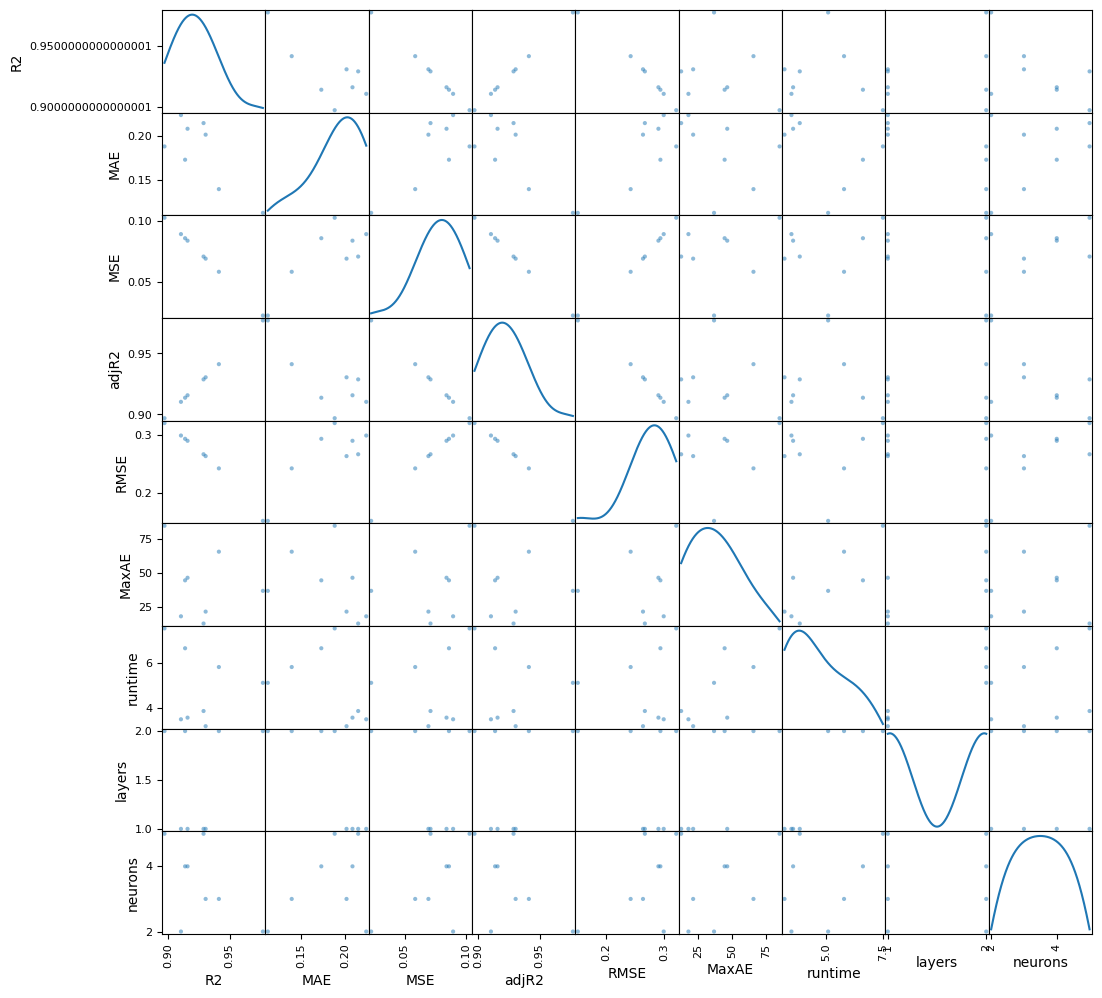

In [56]:
axs = pd.plotting.scatter_matrix(results, figsize=(12,12), grid=True, diagonal='kde')

### [2.2] Grid and Order
Constant 5 neurons, 1 hidden layer, 50 epochs, no pruning or refinement. We will vary the base function between 'silu' and 'identity'. We will vary the grid from 2 to 12 and the order from 1 to 4.

In [68]:
base_functions = ['silu', 'identity']
grid_options = list(range(2,13))
order_options = list(range(1,5))
noise_options = [i*0.1 for i in range(0,10)]

hyprm_options = list(itertools.product(grid_options, order_options))
print(len(hyprm_options))

construction_args={'hidden_layers':[5], 'base_fun':'identity','grid':12,'k':3, 'noise_scale':0.3}
training_args={'steps':50, 'opt':'Adam', 'lr':0.1, 'lamb':0.01, 'singularity_avoiding': True}

44


In [62]:
results = []
for grid, k in hyprm_options:
    construction_args['grid'] = grid
    construction_args['k'] = k
    rdict = (evaluate_hyprm(
                            construction_args=construction_args,
                            training_args=training_args,
                            dataset=dataset
                            ))
    rdict['grid'] = grid
    rdict['order'] = k
    results.append(rdict)
print(len(results))
print(len(results[0].keys()))
results = pd.DataFrame(results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.02e-01 | test_loss: 5.00e-01 | reg: 1.54e+01 | : 100%|█| 50/50 [00:02<00:00, 18.66it


saving model version 0.1
R2: 0.7497172533907527	MAE: 0.4089283353049051	MSE: 0.25015760523594266	AdjR2 0.7493410769178931	RMSE: 0.5001575804043589	MaxAE: 9.382120974108846
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.80e-01 | test_loss: 4.80e-01 | reg: 1.31e+01 | : 100%|█| 50/50 [00:02<00:00, 18.67it


saving model version 0.1
R2: 0.7693359446961481	MAE: 0.40201722794964195	MSE: 0.23054872327619996	AdjR2 0.7689892552342685	RMSE: 0.48015489508719994	MaxAE: 8.022972971132317
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
R2: 0.9562365055761487	MAE: 0.1394771103807228	MSE: 0.0437416126766394	AdjR2 0.9561707287809225	RMSE: 0.20914495613482867	MaxAE: 20.189552998560167
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.13e-01 | test_loss: 2.35e-01 | reg: 1.56e+01 | : 100%|█| 50/50 [00:05<00:00,  9.28it


saving model version 0.1
R2: 0.9449720169609229	MAE: 0.16539455738151987	MSE: 0.0550004690475575	AdjR2 0.9448893095715857	RMSE: 0.23452178800179208	MaxAE: 28.687282935595068
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.39e-01 | test_loss: 2.57e-01 | reg: 1.52e+01 | : 100%|█| 50/50 [00:06<00:00,  7.32it

saving model version 0.1
R2: 0.9339822527757623	MAE: 0.17491707951426713	MSE: 0.06598473835062557	AdjR2 0.933883027704784	RMSE: 0.25687494691118784	MaxAE: 15.935963461122792
44
9


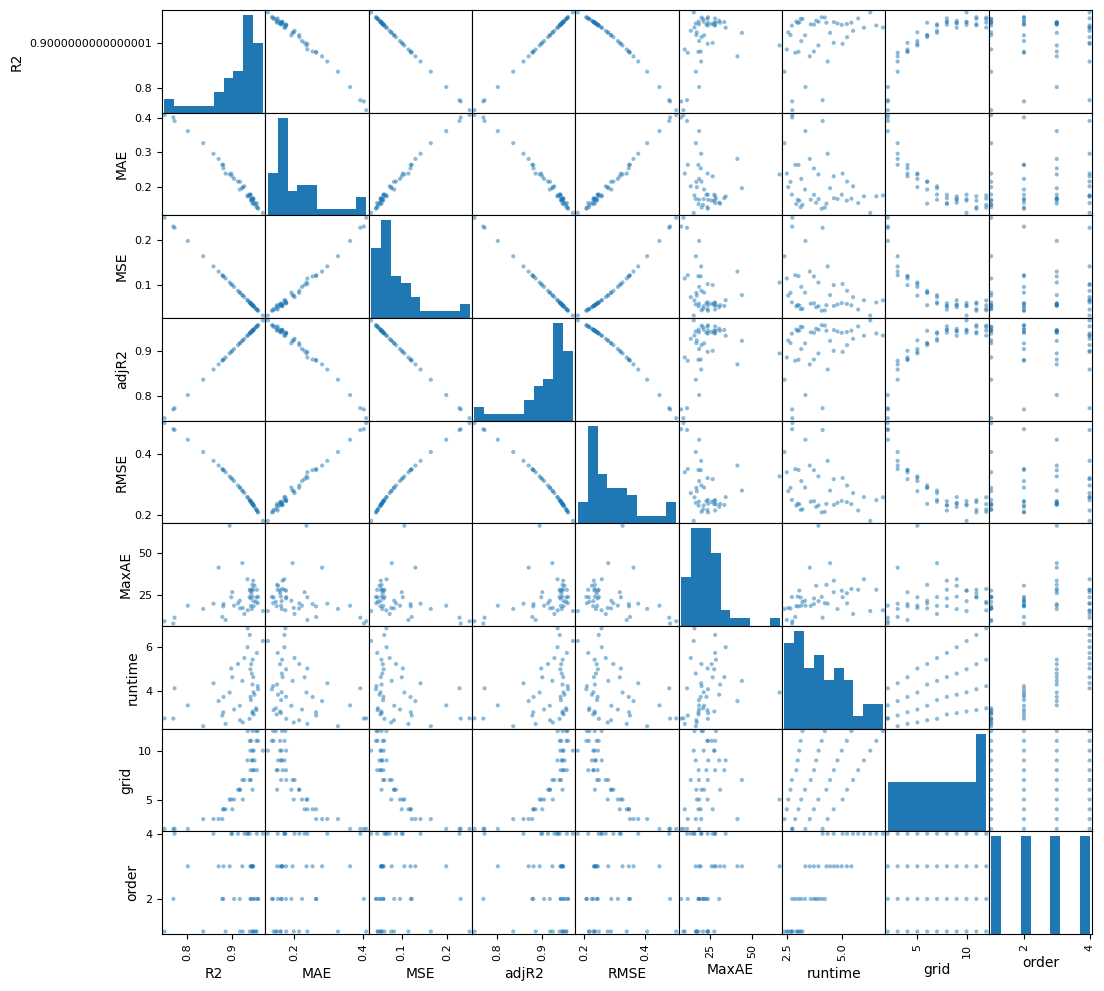

In [63]:
axs = pd.plotting.scatter_matrix(results, figsize=(12,12), grid=True, diagonal='hist')

In [70]:
hyprm_options = list(itertools.product(base_functions, noise_options))
construction_args={'hidden_layers':[5], 'base_fun':'identity','grid':12,'k':3, 'noise_scale':0.3}
training_args={'steps':50, 'opt':'Adam', 'lr':0.1, 'lamb':0.01, 'singularity_avoiding': True}

results = []
for bf, ns in hyprm_options:
    construction_args['base_fun'] = bf
    construction_args['noise_scale'] = ns
    rdict = (evaluate_hyprm(
                            construction_args=construction_args,
                            training_args=training_args,
                            dataset=dataset
                            ))
    rdict['base'] = 0 if bf == 'identity' else 1
    rdict['noise'] = ns
    results.append(rdict)
print(len(results))
print(len(results[0].keys()))
results = pd.DataFrame(results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.28e-02 | test_loss: 1.28e-01 | reg: 9.42e+00 | : 100%|█| 50/50 [00:06<00:00,  7.61it


saving model version 0.1
R2: 0.9836968984333502	MAE: 0.06551013939062543	MSE: 0.01629495001586646	AdjR2 0.9836723947736808	RMSE: 0.1276516745517522	MaxAE: 26.905470435844975
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.91e-02 | test_loss: 1.21e-01 | reg: 9.15e+00 | : 100%|█| 50/50 [00:06<00:00,  8.26it


saving model version 0.1
R2: 0.9853609495027172	MAE: 0.05478692615291081	MSE: 0.014631730972034108	AdjR2 0.9853389469218095	RMSE: 0.12096169216753752	MaxAE: 26.002191639093805
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
R2: 0.9438660481407875	MAE: 0.16017487022154667	MSE: 0.05610588488328291	AdjR2 0.9437816784736643	RMSE: 0.23686680831911192	MaxAE: 30.10815874436898
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.10e-01 | test_loss: 2.37e-01 | reg: 1.46e+01 | : 100%|█| 50/50 [00:06<00:00,  8.21it


saving model version 0.1
R2: 0.9440361894739705	MAE: 0.16056685505040605	MSE: 0.05593582862076653	AdjR2 0.9439520755302941	RMSE: 0.23650756567341885	MaxAE: 30.04397121018997
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.16e-01 | test_loss: 2.40e-01 | reg: 1.47e+01 | : 100%|█| 50/50 [00:06<00:00,  8.21it

saving model version 0.1
R2: 0.9423507045101904	MAE: 0.16919814088292584	MSE: 0.05762047084206466	AdjR2 0.9422640572724803	RMSE: 0.24004264379910636	MaxAE: 33.19832926947636
20
9


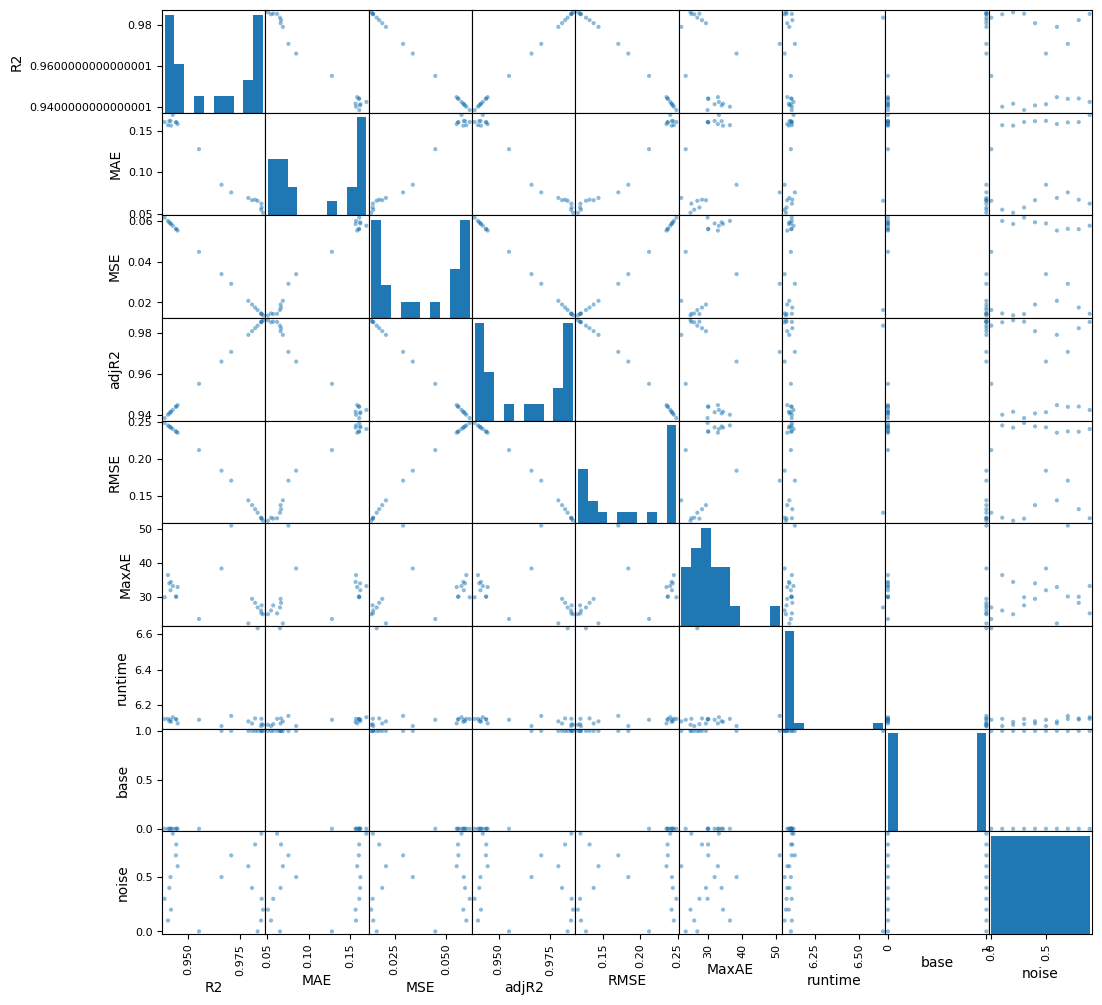

In [71]:
axs = pd.plotting.scatter_matrix(results, figsize=(12,12), grid=True, diagonal='hist')

## [3] Training Hyperparameters

### [3.1] Solver, Learning Rate, Epochs

In [77]:
solver_options = ['LBFGS', 'Adam']
learning_rate_options = [i*0.01 for i in range(1, 100, 10)]
epochs_options = [i for i in range(50,150,25)]

hyprm_options = list(itertools.product(solver_options, learning_rate_options, epochs_options))
print(len(hyprm_options))

construction_args={'hidden_layers':[5], 'base_fun':'identity','grid':12,'k':3, 'noise_scale':0.3}
training_args={'steps':50, 'opt':'Adam', 'lr':0.1, 'lamb':0.01, 'singularity_avoiding': True}

80


In [78]:
results = []
for s, lr, e in hyprm_options:
    training_args['opt'] = s
    training_args['lr'] = lr
    training_args['steps'] = e
    rdict = (evaluate_hyprm(
                            construction_args=construction_args,
                            training_args=training_args,
                            dataset=dataset
                            ))
    rdict['opt'] = 0 if s == 'Adam' else 1
    rdict['lr'] = lr
    rdict['steps'] = e 
    results.append(rdict)
print(len(results))
print(len(results[0].keys()))
results = pd.DataFrame(results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.60e-01 | test_loss: 1.89e-01 | reg: 1.35e+01 | : 100%|█| 50/50 [01:57<00:00,  2.35s/


saving model version 0.1
R2: 0.9641790600536653	MAE: 0.11516280132371426	MSE: 0.03580302947636159	AdjR2 0.9641252209655696	RMSE: 0.18921688475493298	MaxAE: 31.736801553436287
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.57e-01 | test_loss: 1.87e-01 | reg: 1.33e+01 | : 100%|█| 75/75 [02:55<00:00,  2.34s/


saving model version 0.1
R2: 0.9650124275234606	MAE: 0.11033491261353634	MSE: 0.03497007869030114	AdjR2 0.9649598409916822	RMSE: 0.18700288417642424	MaxAE: 45.0947236228673
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
R2: 0.9706144556346874	MAE: 0.09133241949344878	MSE: 0.02937085159312994	AdjR2 0.9705702889848398	RMSE: 0.17137926243606588	MaxAE: 49.955741460236126
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.28e-01 | test_loss: 1.77e-01 | reg: 8.13e+00 | : 100%|█| 50/50 [01:45<00:00,  2.11s/


saving model version 0.1
R2: 0.9686295469054544	MAE: 0.10068105829749092	MSE: 0.031354767867998325	AdjR2 0.9685823969258535	RMSE: 0.17707277562628967	MaxAE: 40.87700434769231
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.28e-01 | test_loss: 1.76e-01 | reg: 8.09e+00 | :  81%|▊| 61/75 [02:09<00:29,  2.12s/


KeyboardInterrupt: 

c:\Users\nhsnow2\AppData\Local\anaconda3\envs\KAN\lib\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
c:\Users\nhsnow2\AppData\Local\anaconda3\envs\KAN\lib\site-packages\pandas\plotting\_matplotlib\misc.py:102: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
c:\Users\nhsnow2\AppData\Local\anaconda3\envs\KAN\lib\site-packages\pandas\plotting\_matplotlib\misc.py:92: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


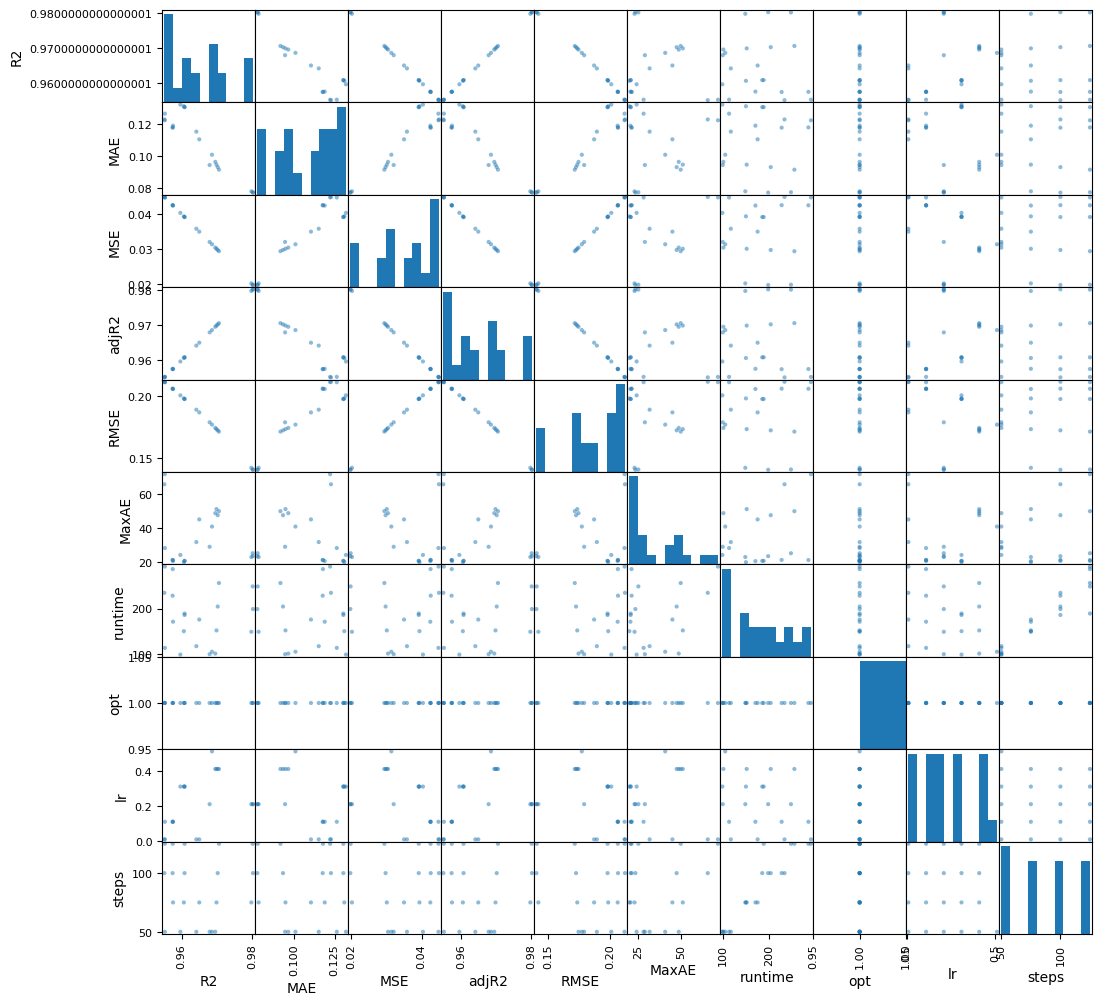

In [80]:
results = pd.DataFrame(results)
axs = pd.plotting.scatter_matrix(results, figsize=(12,12), grid=True, diagonal='hist')

## [4] Tuning Via Ax

In [81]:
from ax.service.ax_client import AxClient, ObjectiveProperties
from ax.utils.notebook.plotting import render 

In [ ]:
optimizer = AxClient(verbose_logging=False)
experiment = optimizer.create_experiment(
                                         name='test_experiment',
                                         parameters=[{"name":"grid",
                                                      "type":"range",
                                                      "bounds":[3,16],
                                                      "value_type":}]
)